In [1]:
# ── Imports ──
# Schwarber V1 — same architecture as Witt V10
# 9 features: era, k_per_9, park_factor, pitcher_r, is_home,
#             avg_exit_velo_15, barrel_rate_15, hard_hit_rate_15, hr_zone_rate_15
# Key differences from Witt:
#   - Schwarber bats LEFT — pitcher_r direction may differ
#   - Citizens Bank Park (team_id 143) — park factor 102
#   - Higher strikeout rate — Statcast features may behave differently
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine


In [2]:
# ── Load base dataset from database ──
# Schwarber player_id = 656941
PLAYER_ID = 656941

with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.k_per_9,
            pf.park_factor,
            pf.park_factor_hr
        FROM player_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 143
                 ELSE w.opponent_id
            END = pf.team_id
        )
        WHERE w.player_id = :pid
        ORDER BY w.date
    """), conn, params={"pid": PLAYER_ID})

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb', 'era']].head(10))


Base dataset: (638, 12)
         date  hr  tb   era
0  2022-04-08   1   5  4.20
1  2022-04-09   0   0  4.20
2  2022-04-10   0   0  4.20
3  2022-04-11   0   0  4.20
4  2022-04-12   0   0  0.00
5  2022-04-13   0   0  4.50
6  2022-04-14   0   2  3.60
7  2022-04-15   0   0  1.80
8  2022-04-17   1   5  7.71
9  2022-04-18   0   0  2.08


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"\n(Witt baseline for comparison: 16.0%)")


HR distribution:
hr
0    474
1    142
2     19
3      2
4      1
Name: count, dtype: int64

Games with 0 HR:  0.743
Games with 1+ HR: 0.257 (25.7% of games)
Games with 2+ HR: 0.034

Break-even American odds: -35

(Witt baseline for comparison: 16.0%)


In [4]:
# ── Pull Statcast data via pybaseball ──
# Schwarber player_id = 656941
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=656941)
print(f"Statcast raw: {statcast_raw.shape}")


Pulling Statcast data...
Gathering Player Data
Statcast raw: (13182, 118)


In [5]:
# ── Aggregate Statcast to game level ──
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle band — where balls most frequently leave the park
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (688, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-02     0.000000      0.000000
1  2022-04-03     0.166667      0.166667
2  2022-04-05     0.500000      0.500000
3  2022-04-06     0.000000      0.000000
4  2022-04-08     0.200000      0.200000
5  2022-04-09     0.000000      0.000000
6  2022-04-10     0.000000      0.000000
7  2022-04-11     0.000000      0.000000
8  2022-04-12     0.000000      0.000000
9  2022-04-13     0.000000      0.000000


In [6]:
# ── Rolling Statcast features — 15-day window ──
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-02             NaN              NaN
1   2022-04-03             NaN              NaN
2   2022-04-05             NaN              NaN
3   2022-04-06             NaN              NaN
4   2022-04-08             NaN              NaN
5   2022-04-09             NaN              NaN
6   2022-04-10             NaN              NaN
7   2022-04-11        0.123810         0.123810
8   2022-04-12        0.108333         0.108333
9   2022-04-13        0.096296         0.096296
10  2022-04-14        0.086667         0.086667
11  2022-04-15        0.091775         0.078788
12  2022-04-17        0.084127         0.072222
13  2022-04-18        0.090476         0.079487
14  2022-04-19        0.084014         0.082738
15  2022-04-20        0.078413         0.105794
16  2022-04-22        0.095079         0.139127
17  2022-04-23        0.083968         0.128016
18  2022-04-24        0.050635         0.094683
19  2022-04-25        0.083968         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (638, 17)
avg_exit_velo_15    16
barrel_rate_15      16
hr_zone_rate_15     16
dtype: int64


In [8]:
# ── Feature engineering ──
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Note: Schwarber bats LEFT — pitcher_r expected > 1 (lefties hit more HRs vs RHP)
# This is the same direction as Witt but the platoon advantage works differently

# Drop rows missing Statcast rolling features only
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")


Model dataset: (622, 19)


In [9]:
# ── Define features and binary target ──
# Same 9-feature architecture as Witt V10
# pitcher_r: Schwarber bats left — expect stronger platoon effect vs RHP
FEATURES = [
    # Schwarber contact quality
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',
    # Game context
    'is_home',
    'pitcher_r',
    # Pitcher
    'era',
    'k_per_9',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")
print(f"\n(Witt HR rate for comparison: 0.160)")


Features: 9
Dataset: (622, 9)
HR rate: 0.257 (160 HR games out of 622)

(Witt HR rate for comparison: 0.160)


In [10]:
# ── Scale features ──
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.743
Break-even odds for HR prop: -35


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        10.0
Best CV AUC:   0.529

 param_C  mean_test_score  std_test_score
   0.001           0.5191          0.0830
   0.010           0.5201          0.0807
   0.050           0.5236          0.0779
   0.100           0.5224          0.0762
   0.250           0.5232          0.0727
   0.500           0.5251          0.0715
   1.000           0.5265          0.0711
   2.000           0.5279          0.0720
   5.000           0.5292          0.0721
  10.000           0.5294          0.0725


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean +/- std: {cv_auc.mean():.3f} +/- {cv_auc.std():.3f}")
print(f"ACC mean +/- std: {cv_acc.mean():.3f} +/- {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nSchwarber V1 CV AUC: {cv_auc.mean():.3f}")
print(f"Witt V10 CV AUC:     0.567  (for reference)")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")


CV AUC per fold:  [np.float64(0.576), np.float64(0.398), np.float64(0.515), np.float64(0.608), np.float64(0.551)]
CV ACC per fold:  [np.float64(0.748), np.float64(0.709), np.float64(0.796), np.float64(0.738), np.float64(0.699)]

AUC mean +/- std: 0.529 +/- 0.073
ACC mean +/- std: 0.738 +/- 0.034

Baseline ACC:     0.743
Improvement:      -0.005

Schwarber V1 CV AUC: 0.529
Witt V10 CV AUC:     0.567  (for reference)

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.581
In-sample ACC:  0.743
CV AUC:         0.529

Gap (in-sample - CV AUC): 0.052
(smaller gap = less overfitting)

Mean P(HR):     0.257
Actual HR rate: 0.257


In [15]:
# ── Calibration table ──
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V6 spread:              0.185")
print(f"V5 spread:              ~0.12")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.195        0.184  125
1                  0.230        0.266  124
2                  0.250        0.194  124
3                  0.279        0.282  124
4                  0.333        0.360  125

Spread (bin 4 - bin 0): 0.176
V6 spread:              0.185
V5 spread:              ~0.12

(larger spread = better discrimination between HR and non-HR games)


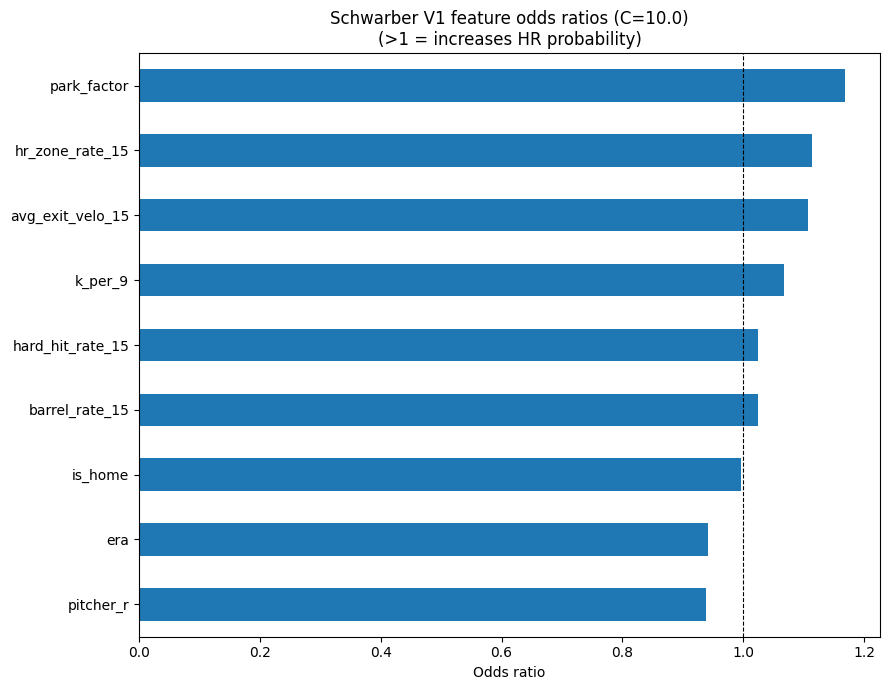


Odds ratios:
pitcher_r           0.939
era                 0.942
is_home             0.997
barrel_rate_15      1.024
hard_hit_rate_15    1.024
k_per_9             1.067
avg_exit_velo_15    1.107
hr_zone_rate_15     1.114
park_factor         1.168
dtype: float64


In [16]:
# ── Feature odds ratios ──
# Expected directions:
#   era        > 1 — higher ERA = worse pitcher = more HRs
#   k_per_9    < 1 — strikeout pitchers limit balls in play
#   park_factor > 1 — hitter-friendly parks = more HRs
#   pitcher_r  > 1 — Schwarber bats left, platoon advantage vs RHP
#   is_home    > 1 — home field advantage (Citizens Bank Park)
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 7))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'Schwarber V1 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))


In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
602 2025-09-07  0.175711           469  ❌ No HR
603 2025-09-08  0.242492           312  ❌ No HR
604 2025-09-09  0.272387           267     ✅ HR
605 2025-09-10  0.238956           318  ❌ No HR
606 2025-09-11  0.286622           249  ❌ No HR
607 2025-09-12  0.257878           288  ❌ No HR
608 2025-09-13  0.274625           264     ✅ HR
609 2025-09-14  0.303732           229     ✅ HR
610 2025-09-15  0.341668           193     ✅ HR
611 2025-09-16  0.343290           191  ❌ No HR
612 2025-09-17  0.352656           184  ❌ No HR
613 2025-09-19  0.272139           267  ❌ No HR
614 2025-09-20  0.272432           267  ❌ No HR
615 2025-09-21  0.309995           223  ❌ No HR
616 2025-09-23  0.297694           236     ✅ HR
617 2025-09-24  0.317882           215     ✅ HR
618 2025-09-25  0.279433           258  ❌ No HR
619 2025-09-26  0.289850           245  ❌ No HR
620 2025-09-27  0.251584           2

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/schwarber_hr_logistic_v1_model.pkl')
joblib.dump(scaler, '../models/schwarber_hr_logistic_v1_scaler.pkl')
print("Saved:")
print("  models/schwarber_hr_logistic_v1_model.pkl")
print("  models/schwarber_hr_logistic_v1_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")


Saved:
  models/schwarber_hr_logistic_v1_model.pkl
  models/schwarber_hr_logistic_v1_scaler.pkl

Best C: 10.0
Features (9): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'k_per_9', 'park_factor']
